# 실습 4: 센서 하나로 이상 구간 찾기
- 상황: 3라인 계측 기록에서 평소와 다르게 튄 구간을 찾아본다
- 목표: 관리선을 긋고 벗어난 구간을 잡는다

## Step 1. 불러오기와 기본 확인

In [1]:
import pandas as pd

df = pd.read_csv('../../data/04_secom.csv')

# 1. 전체 행 수와 열 수
print('행 수, 열 수:', df.shape)

# 2. result 열의 값 종류별 건수와 비율
print('\nresult 열 건수:')
print(df['result'].value_counts())
print('\nresult 열 비율:')
print(df['result'].value_counts(normalize=True))

# 3. head() 확인
pd.set_option('display.max_columns', None)
df.head()

행 수, 열 수: (1567, 592)

result 열 건수:
result
양품    1463
불량     104
Name: count, dtype: int64

result 열 비율:
result
양품    0.933631
불량    0.066369
Name: proportion, dtype: float64


,measured_at,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,sensor_011,sensor_012,sensor_013,sensor_014,sensor_015,sensor_016,sensor_017,sensor_018,sensor_019,sensor_020,sensor_021,sensor_022,sensor_023,sensor_024,sensor_025,sensor_026,sensor_027,sensor_028,sensor_029,sensor_030,sensor_031,sensor_032,sensor_033,sensor_034,sensor_035,sensor_036,sensor_037,sensor_038,sensor_039,sensor_040,sensor_041,sensor_042,sensor_043,sensor_044,sensor_045,sensor_046,sensor_047,sensor_048,sensor_049,sensor_050,sensor_051,sensor_052,sensor_053,sensor_054,sensor_055,sensor_056,sensor_057,sensor_058,sensor_059,sensor_060,sensor_061,sensor_062,sensor_063,sensor_064,sensor_065,sensor_066,sensor_067,sensor_068,sensor_069,sensor_070,sensor_071,sensor_072,sensor_073,sensor_074,sensor_075,sensor_076,sensor_077,sensor_078,sensor_079,sensor_080,sensor_081,sensor_082,sensor_083,sensor_084,sensor_085,sensor_086,sensor_087,sensor_088,sensor_089,sensor_090,sensor_091,sensor_092,sensor_093,sensor_094,sensor_095,sensor_096,sensor_097,sensor_098,sensor_099,sensor_100,sensor_101,sensor_102,sensor_103,sensor_104,sensor_105,sensor_106,sensor_107,sensor_108,sensor_109,sensor_110,sensor_111,sensor_112,sensor_113,sensor_114,sensor_115,sensor_116,sensor_117,sensor_118,sensor_119,sensor_120,sensor_121,sensor_122,sensor_123,sensor_124,sensor_125,sensor_126,sensor_127,sensor_128,sensor_129,sensor_130,sensor_131,sensor_132,sensor_133,sensor_134,sensor_135,sensor_136,sensor_137,sensor_138,sensor_139,sensor_140,sensor_141,sensor_142,sensor_143,sensor_144,sensor_145,sensor_146,sensor_147,sensor_148,sensor_149,sensor_150,sensor_151,sensor_152,sensor_153,sensor_154,sensor_155,sensor_156,sensor_157,sensor_158,sensor_159,sensor_160,sensor_161,sensor_162,sensor_163,sensor_164,sensor_165,sensor_166,sensor_167,sensor_168,sensor_169,sensor_170,sensor_171,sensor_172,sensor_173,sensor_174,sensor_175,sensor_176,sensor_177,sensor_178,sensor_179,sensor_180,sensor_181,sensor_182,sensor_183,sensor_184,sensor_185,sensor_186,sensor_187,sensor_188,sensor_189,sensor_190,sensor_191,sensor_192,sensor_193,sensor_194,sensor_195,sensor_196,sensor_197,sensor_198,sensor_199,sensor_200,sensor_201,sensor_202,sensor_203,sensor_204,sensor_205,sensor_206,sensor_207,sensor_208,sensor_209,sensor_210,sensor_211,sensor_212,sensor_213,sensor_214,sensor_215,sensor_216,sensor_217,sensor_218,sensor_219,sensor_220,sensor_221,sensor_222,sensor_223,sensor_224,sensor_225,sensor_226,sensor_227,sensor_228,sensor_229,sensor_230,sensor_231,sensor_232,sensor_233,sensor_234,sensor_235,sensor_236,sensor_237,sensor_238,sensor_239,sensor_240,sensor_241,sensor_242,sensor_243,sensor_244,sensor_245,sensor_246,sensor_247,sensor_248,sensor_249,sensor_250,sensor_251,sensor_252,sensor_253,sensor_254,sensor_255,sensor_256,sensor_257,sensor_258,sensor_259,sensor_260,sensor_261,sensor_262,sensor_263,sensor_264,sensor_265,sensor_266,sensor_267,sensor_268,sensor_269,sensor_270,sensor_271,sensor_272,sensor_273,sensor_274,sensor_275,sensor_276,sensor_277,sensor_278,sensor_279,sensor_280,sensor_281,sensor_282,sensor_283,sensor_284,sensor_285,sensor_286,sensor_287,sensor_288,sensor_289,sensor_290,sensor_291,sensor_292,sensor_293,sensor_294,sensor_295,sensor_296,sensor_297,sensor_298,sensor_299,sensor_300,sensor_301,sensor_302,sensor_303,sensor_304,sensor_305,sensor_306,sensor_307,sensor_308,sensor_309,sensor_310,sensor_311,sensor_312,sensor_313,sensor_314,sensor_315,sensor_316,sensor_317,sensor_318,sensor_319,sensor_320,sensor_321,sensor_322,sensor_323,sensor_324,sensor_325,sensor_326,sensor_327,sensor_328,sensor_329,sensor_330,sensor_331,sensor_332,sensor_333,sensor_334,sensor_335,sensor_336,sensor_337,sensor_338,sensor_339,sensor_340,sensor_341,sensor_342,sensor_343,sensor_344,sensor_345,sensor_346,sensor_347,sensor_348,sensor_349,sensor_350,sensor_351,sensor_352,sensor_353,sensor_354,sensor_355,sensor_356,sensor_357,sensor_358,sensor_359,sensor_360,sensor_361,sensor_362,senso

---

## Step 2. 관리도라는 말부터

### 용어 풀이 - 관리도 주변

| 말 | 뜻 |
|---|---|
| 관리도 | 값을 시간 순서대로 그려두고, 평소 범위를 벗어나는 순간을 잡는 그림 |
| 관리선 | 평소 범위의 경계선. 위쪽 선을 관리 상한, 아래쪽 선을 관리 하한이라 부른다 |
| 평균 | 값들을 다 더해 개수로 나눈 것. 관리도의 한가운데 선이 된다 |
| 표준편차 | 값들이 평균에서 얼마나 흩어져 있는지. 작으면 몰려 있고 크면 넓게 퍼져 있다 |
| 이상 구간 | 관리선을 벗어난 구간. 벗어났다는 것이지 곧 불량이라는 뜻은 아니다 |
| result (판정) | 검사에서 붙은 양품 또는 불량. 공정이 다 끝난 뒤에 붙는다 |
| SPC | 이런 방식으로 공정을 감시하는 것을 통틀어 부르는 말 |

## Step 3. 센서 하나 고르기

In [2]:
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

# 결측치 없고, 값이 하나로만 고정되지 않은(변하는) 센서 열만 추리기
no_na_non_const = [
    c for c in sensor_cols
    if df[c].isna().sum() == 0 and df[c].nunique() > 1
]
print('조건(결측 없음 + 값이 변함)을 만족하는 센서 열 수:', len(no_na_non_const))

picked = no_na_non_const[:5]
print('고른 센서 5개:', picked)

def magnitude_note(vmax_abs):
    # 자릿수(크기)만 보고 성격을 대략 짐작 - 실제 단위/의미는 알 수 없으므로 항상 '불확실' 표시
    if vmax_abs < 1:
        return '1보다 작은 값 - 비율/미세값일 수 있음 (불확실)'
    elif vmax_abs < 10:
        return '한 자리 값 - 비율/계수일 수 있음 (불확실)'
    elif vmax_abs < 1000:
        return '두세 자리 값 - 온도·압력 같은 눈금성 측정값일 수 있음 (불확실)'
    else:
        return '네 자리 이상 큰 값 - 큰 수로 세는 값이거나 눈금이 큰 계측값일 수 있음 (불확실)'

rows = []
for c in picked:
    s = df[c]
    vmin, vmax, n_unique = s.min(), s.max(), s.nunique()

    if n_unique <= 10:
        verdict = '정해 넣은 값에 가까움'
    elif n_unique >= 20:
        verdict = '재고 있는 값에 가까움'
    else:
        verdict = '판단 애매함 (열 가지~수십 가지 사이, 불확실)'

    rows.append({
        '센서 이름': c,
        '값의 범위 (최소 ~ 최대)': f'{vmin} ~ {vmax}',
        '고유값 개수': n_unique,
        '판정 (종류 수 기준)': verdict,
        '자릿수로 본 성격 (추정, 불확실)': magnitude_note(max(abs(vmin), abs(vmax))),
    })

summary_df = pd.DataFrame(rows)
summary_df

조건(결측 없음 + 값이 변함)을 만족하는 센서 열 수: 52
고른 센서 5개: ['sensor_021', 'sensor_087', 'sensor_088', 'sensor_089', 'sensor_114']


,센서 이름,값의 범위 (최소 ~ 최대),고유값 개수,판정 (종류 수 기준),"자릿수로 본 성격 (추정, 불확실)"
0,sensor_021,1.1797 ~ 1.4534,552,재고 있는 값에 가까움,한 자리 값 - 비율/계수일 수 있음 (불확실)
1,sensor_087,2.2425 ~ 2.5555,472,재고 있는 값에 가까움,한 자리 값 - 비율/계수일 수 있음 (불확실)
2,sensor_088,0.7749 ~ 0.9935,249,재고 있는 값에 가까움,1보다 작은 값 - 비율/미세값일 수 있음 (불확실)
3,sensor_089,1627.4714 ~ 2105.1823,973,재고 있는 값에 가까움,네 자리 이상 큰 값 - 큰 수로 세는 값이거나 눈금이 큰 계측값일 수 있음 (불확실)
4,sensor_114,0.8534 ~ 0.9763,468,재고 있는 값에 가까움,1보다 작은 값 - 비율/미세값일 수 있음 (불확실)


[내가 고른 열]<br>
고른 열 : [sensor_089]<br>
값 범위 : [1627.47] ~ [2105.18]   값 종류 : [973]가지<br>
값 종류가 [많으니] 이 열은 [재고 있는 값]에 가깝다<br>
AI가 본 성격 : [네 자리 이상 — 큰 수로 세는 값]

→ 추측 : Thickness[Å] - masking layer  (1Å = 0.1nm)

| 순위    | 막                           | 적용 소자/구조                                              | 대표 재료         | 가능성       | 판단 이유                                                    | 주로 사용되는 두께 범위*                     | 주요 기능                                |
| ----- | --------------------------- | ----------------------------------------------------- | ------------- | --------- | -------------------------------------------------------- | ---------------------------------- | ------------------------------------ |
| **1** | **Photoresist (PR)**        | DRAM / NAND / Logic 등 대부분의 소자                         | CAR 계열 PR 등   | **높음**    | **163~211 nm**는 미세 패터닝용 PR에서 충분히 가능한 범위                  | **약 50~500 nm**                    | 노광·현상으로 회로 패턴 형성, 후속 식각·이온주입의 마스크 역할 |
| **2** | **SiO₂ / SiN Hard Mask**    | DRAM Storage Node / 3D NAND Channel Hole / Logic 미세패턴 | SiO₂, SiN     | **높음**    | 수백 nm급 hard mask가 사용될 수 있어 해당 범위와 잘 부합                   | **약 50~500 nm**, HARC용은 더 두꺼울 수 있음 | 장시간 식각에서 PR을 보조하고 패턴을 하부막으로 전달       |
| **3** | **ILD / IMD**               | DRAM / NAND / Logic 배선 구조                             | SiO₂, SiCOH 등 | **중~높음**  | 층간 절연막은 100 nm 이상이 흔해 해당 범위가 자연스러움                       | **약 100~1,000 nm**                 | 트랜지스터 및 금속 배선층 사이 전기적 절연             |
| **4** | **Passivation Layer**       | DRAM / NAND / Logic / Power 소자 최상부                    | SiN, SiO₂     | **중~높음**  | 수백 nm 이상의 최종 보호막이 사용되므로 163~211 nm도 가능                   | **약 200 nm~1 µm 이상**               | 수분·이온·오염 및 기계적 손상으로부터 칩 보호           |
| **5** | **STI Fill Oxide**          | DRAM Cell·Peripheral / Logic Transistor               | SiO₂          | **중간**    | STI 깊이·충전막 규모가 100 nm 이상일 수 있으나 단순 막 두께와 직접 비교할 때는 주의 필요 | **약 100~500 nm 수준의 trench depth**  | 인접 트랜지스터 사이 전기적 격리                   |
| **6** | **Metal Interconnect Film** | DRAM / NAND / Logic 배선 구조                             | W, Cu, Al 등   | **중간 이하** | 일부 배선·plug·금속막은 100 nm 이상이지만 배선 레벨별 차이가 큼                | **약 수십~수백 nm**, 상부 배선은 **µm급 가능**  | 소자 간 신호 및 전원 전달                      |


---

## Step 4. 평소 범위를 정하기
평균에서 표준편차 3배만큼 위아래로 관리선을 긋는다.

In [3]:
# 앞에서 고른 센서 이름을 넣는다 (본인이 고른 것으로 바꾸세요)
센서 = "sensor_089"

# 평균 — 이 센서 값들의 한가운데
평균 = df[센서].mean()

# 표준편차 — 값들이 평균에서 얼마나 흩어져 있는지
표준편차 = df[센서].std()

# 관리 상한 / 하한 — 평균에서 표준편차 3배만큼 위아래
위선 = 평균 + 3 * 표준편차
아래선 = 평균 - 3 * 표준편차

# round(값, 2) — 소수점 둘째 자리까지만 보여준다
print("평균:", round(평균, 2))
print("관리 상한:", round(위선, 2))
print("관리 하한:", round(아래선, 2))

평균: 1807.82
관리 상한: 1968.43
관리 하한: 1647.2


---

## Step 5. 관리도 그리기

저장 위치: C:\Users\subin\OneDrive\바탕 화면\secome-project\day02\lab04_control-chart\results\control_chart_sensor_089.png


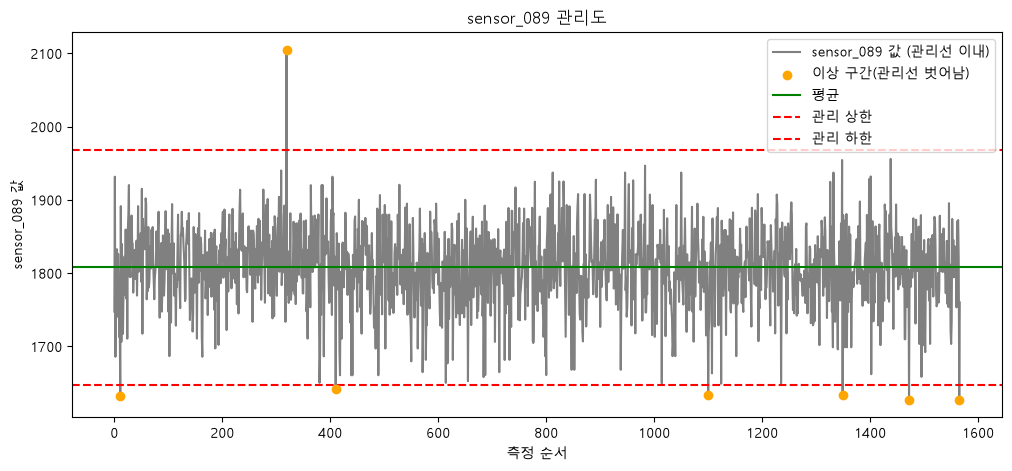

In [4]:
# 그림 그리는 도구를 plt라는 짧은 이름으로 불러온다
import matplotlib.pyplot as plt
import os

# 한글이 그림에서 깨지지 않도록 폰트를 지정한다 (Windows에 있는 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 결과 그림을 저장할 results 폴더 만들기 (이미 있으면 그대로 둔다)
os.makedirs("results", exist_ok=True)

# 관리선(위선/아래선)을 벗어난 점만 따로 골라내기
벗어난_점 = df[센서][(df[센서] > 위선) | (df[센서] < 아래선)]

plt.figure(figsize=(12, 5))

# 센서 값을 측정 순서대로 선으로 그린다 (관리선 안쪽이 대부분이라 회색으로 그린다)
plt.plot(df[센서], color="gray", label=f"{센서} 값 (관리선 이내)")

# 관리선을 벗어난 점만 다른 색(주황 점)으로 덧그린다
plt.scatter(벗어난_점.index, 벗어난_점, color="orange", zorder=3, label="이상 구간(관리선 벗어남)")

# axhline — 가로로 쭉 뻗는 선 하나를 긋는다, label로 이름표를 붙인다
plt.axhline(평균, color="green", label="평균")
plt.axhline(위선, color="red", linestyle="--", label="관리 상한")
plt.axhline(아래선, color="red", linestyle="--", label="관리 하한")

# 제목과 축 이름 넣기
plt.title(f"{센서} 관리도")
plt.xlabel("측정 순서")
plt.ylabel(f"{센서} 값")

# legend — 각 선/점에 붙인 label을 모아 이름표 상자로 보여준다
plt.legend()

# 그림을 results 폴더 안에 저장한다 (노트북이 있는 폴더 기준 상대 경로)
저장_경로 = os.path.join("results", f"control_chart_{센서}.png")
plt.savefig(저장_경로, dpi=150, bbox_inches="tight")
print("저장 위치:", os.path.abspath(저장_경로))

# 그림을 화면에 띄운다
plt.show()

**선을 넘은 점 : [7]개<br>
그중 관리 상한을 넘은 점 : [1]개   
관리 하한 아래로 내려간 점 : [6]개**

### 문법 노트 - 그림 그리기 첫걸음

| 쓴 것 | 하는 일 |
|---|---|
| plt.plot(값들) | 값을 순서대로 이어 선으로 그린다 |
| plt.axhline(높이) | 그 높이에 가로선 하나를 긋는다. 관리선이 바로 이것 |
| color="red" | 선 색을 정한다 |
| linestyle="--" | 선을 점선으로 만든다 (실선인 평균선과 구분되게) |
| plt.show() | 지금까지 얹은 것들을 한 장으로 띄운다 |
| round(값, 2) | 소수점 둘째 자리까지만 남긴다 |

**한 장의 도화지에 하나씩 얹는 방식이다.**<br>
선을 그리고, 그 위에 가로선을 세 개 얹고, 마지막에 show로 완성해서 보여준다.<br>
그래서 순서대로 쭉 쓰면 된다.

---

## Step 6. 선을 넘은 것이 불량이었나

In [5]:
# 관리 상한 또는 하한을 벗어난 행만 골라내기
벗어난_행 = df[(df[센서] > 위선) | (df[센서] < 아래선)]

상한_초과_수 = (벗어난_행[센서] > 위선).sum()
하한_미만_수 = (벗어난_행[센서] < 아래선).sum()

print(f"벗어난 행 수: {len(벗어난_행)} / 전체: {len(df)}")
print(f"관리 상한을 넘은 점: {상한_초과_수} 개")
print(f"관리 하한 아래로 내려간 점: {하한_미만_수} 개")

print("\n[벗어난 행]")
print(벗어난_행[[센서, 'result']])

print(f"\n⚠ 벗어난 행이 {len(벗어난_행)}건뿐이라 비율이 크게 흔들린다. 한 건 차이로 비율이 확 바뀐다.")

# 벗어난 행과 전체를 result 기준으로 비교
벗어난_건수 = 벗어난_행['result'].value_counts()
전체_건수 = df['result'].value_counts()

요약_df = pd.DataFrame({
    '벗어난 행': 벗어난_건수,
    '전체': 전체_건수,
})
요약_df['벗어난 행 비율(%)'] = (요약_df['벗어난 행'] / len(벗어난_행) * 100).round(1)
요약_df['전체 비율(%)'] = (요약_df['전체'] / len(df) * 100).round(1)
요약_df.index.name = 'result'
요약_df = 요약_df.loc[['양품', '불량']]
요약_df

벗어난 행 수: 7 / 전체: 1567
관리 상한을 넘은 점: 1 개
관리 하한 아래로 내려간 점: 6 개

[벗어난 행]
      sensor_089 result
11     1632.3120     불량
319    2105.1823     양품
410    1642.5266     양품
1100   1634.0957     양품
1349   1633.1937     양품
1472   1627.4714     양품
1565   1627.4714     양품

⚠ 벗어난 행이 7건뿐이라 비율이 크게 흔들린다. 한 건 차이로 비율이 확 바뀐다.


,벗어난 행,전체,벗어난 행 비율(%),전체 비율(%)
result,,,,
양품,6,1463,85.7,93.4
불량,1,104,14.3,6.6


---

## Step 7. 그런데 590개는요?

센서 1개를 확인하는 데 실행한 코드 칸과 AI 요청 : [5]번<br>
590개를 다 하려면? -> 590 x [5] = [2950]번<br>
게다가 그림 590장을 하나씩 눈으로 봐야 한다.

---
## 직접 해보기 (도전) - 선을 좁히면 어떻게 될까

- 상황: 관리선을 표준편차 3배로 그었다. 이건 관행일 뿐 정답이 아니다
- 할 일: 같은 센서에 2배로 다시 그어 3배일 때와 숫자를 비교한다
- 결과물: 네 줄짜리 비교표 1개

In [6]:
# 전체 불량 비율 (비교 기준)
전체_불량_비율 = (df['result'] == '불량').mean() * 100
print(f"전체 불량 비율: {round(전체_불량_비율, 1)}%")

def 관리선_요약(기준_이름, n_sigma):
    위 = 평균 + n_sigma * 표준편차
    아래 = 평균 - n_sigma * 표준편차
    벗어남 = df[(df[센서] > 위) | (df[센서] < 아래)]
    불량_수 = (벗어남['result'] == '불량').sum()
    불량_비율 = (불량_수 / len(벗어남) * 100) if len(벗어남) > 0 else float('nan')
    대비 = (불량_비율 / 전체_불량_비율) if len(벗어남) > 0 else float('nan')
    return {
        '기준': 기준_이름,
        '관리 하한': round(아래, 2),
        '관리 상한': round(위, 2),
        '벗어난 행': len(벗어남),
        '불량': 불량_수,
        '불량 비율(%)': round(불량_비율, 1),
        '전체(6.6%) 대비': f'{round(대비, 1)}배',
    }

비교표 = pd.DataFrame([
    관리선_요약('A (3배)', 3),
    관리선_요약('B (2배)', 2),
])
비교표

전체 불량 비율: 6.6%


,기준,관리 하한,관리 상한,벗어난 행,불량,불량 비율(%),전체(6.6%) 대비
0,A (3배),1647.20,1968.43,7,1,14.3,2.2배
1,B (2배),1700.74,1914.89,81,5,6.2,0.9배


### 관리선 2배 vs 3배

| 항목 | 3배 | 2배 |
|---|---|---|
| 관리 상한 | [1968.4] | [1914.9] |
| 관리 하한 | [1647.2] | [1700.7] |
| 벗어난 행 수 | [7] | [81] |
| 그 행들의 불량 비율 (%) | [14.3] | [6.2] |

**얻은 인사이트** <br>
A(±3σ) 기준은 이탈 표본이 7건뿐이라 불량 비율(14.3%, 전체 대비 2.2배)이 튀어 보이지만 통계적으로 신뢰하기엔 표본이 너무 적다. <br>관리선을 ±2σ로 좁혀 표본을 81건까지 늘려본 B 기준에서는 오히려 불량 비율이 6.2%로 전체 평균과 비슷하거나 낮게(0.9배) 나와, "관리선을 벗어났다고 곧 불량은 아니다"라는 처음 정의와 일치한다. <br>즉 sensor_089의 관리선 이탈만으로는 불량을 예측하는 근거로 삼기 어렵고, 표본 수와 기준선 폭에 따라 결론이 뒤집힐 수 있다는 점을 염두에 둬야 한다.